# Prevendo Heart Disease com Machine Learning

Este notebook tem como objetivo ser uma introdução a alguns conceitos fundamentais de machine learning e data science, explorando o problema de **classificação** de doenças cardíacas.

Por exemplo, dadas as características de saúde de uma pessoa, vamos construir um modelo para prever se ela tem ou não uma doença cardíaca.

A ideia é que este seja um exemplo completo (ponta a ponta) de como pode ser uma prova de conceito (**proof of concept**) de data science e machine learning.

## O que é classificação?

Classificação envolve decidir se uma amostra pertence a uma classe ou a outra (**classificação binária**).

Se houver múltiplas opções de classe, isso é chamado de **classificação multiclasse**.

## Onde vamos chegar

Vamos começar com o dataset de doenças cardíacas com o qual trabalhamos em módulos anteriores e vamos abordar o problema seguindo o framework de modelagem de machine learning.

Mais especificamente, vamos abordar os seguintes tópicos:

| Etapa | O que vamos cobrir |
|:-----|:-----|
| **Análise exploratória de dados (EDA)** | O processo de examinar um dataset e descobrir mais sobre ele. |
| **Treinamento do modelo**  | Criar modelo(s) que aprendam a prever uma variável alvo com base em outras variáveis. |
| **Avaliação do modelo** | Avaliar as previsões de um modelo usando métricas de avaliação específicas do problema. |
| **Comparação de modelos** | Comparar diversos modelos diferentes para encontrar o melhor. |
| **Ajuste de hiperparâmetros do modelo** | Uma vez que encontramos um bom modelo, conseguimos ajustar seus hiperparâmetros para melhorá-lo? |
| **Importância das features** | Já que estamos prevendo a presença de doença cardíaca, existem features/características mais importantes para a previsão do que outras? |
| **Validação cruzada** | Se construirmos um bom modelo, podemos ter certeza de que ele vai funcionar em dados não vistos? |
| **Reportando o que descobrimos** | Se tivéssemos que apresentar nosso trabalho, o que mostraríamos para alguém? |

Para percorrer esses tópicos, vamos usar pandas, Matplotlib e NumPy para análise de dados, além do Scikit-Learn para tarefas de machine learning e modelagem.

Vamos trabalhar em cada etapa e, ao final do notebook, teremos alguns modelos, todos capazes de prever se uma pessoa tem ou não doença cardíaca com base em diversos parâmetros diferentes, com uma acurácia considerável.

Também devemos ser capazes de descrever quais parâmetros são mais indicativos do que outros — por exemplo, sexo pode ser mais importante do que idade.

## Sumário

- [Prevendo Heart Disease com Machine Learning](#prevendo-heart-disease-com-machine-learning)
  - [O que é classificação?](##o-que-é-classificação)
  - [Onde vamos chegar](#onde-vamos-chegar)
  - [1. Percorrendo o framework de ML em 6 etapas](#1-percorrendo-o-framework-de-ml-em-6-etapas)
    - [1.1 Definição do problema](#11-definição-do-problema)
    - [1.2 Quais dados estamos usando?](#12-quais-dados-estamos-usando)
    - [1.3 Como vamos avaliar nosso modelo?](#13-como-vamos-avaliar-nosso-modelo)
    - [1.4 Quais features dos dados serão importantes para nós?](#14-quais-features-dos-dados-serão-importantes-para-nós)
      - [Dicionário de Dados de Heart Disease](#dicionário-de-dados-de-heart-disease)
  - [2. Preparando as ferramentas](#2-preparando-as-ferramentas)
  - [3. Carregando os Dados](#3-carregando-os-dados)
  - [4. Exploração de Dados (análise exploratória de dados ou EDA)](#4-exploração-de-dados-análise-exploratória-de-dados-ou-eda)
    - [4.1 Comparando uma feature com outra](#41-comparando-uma-feature-com-outra)
    - [4.2 Visualizando nossa comparação](#42-visualizando-nossa-comparação)
    - [4.3 Comparando idade e frequência cardíaca máxima](#43-comparando-idade-e-frequência-cardíaca-máxima)
    - [4.4 Comparando frequência de doença cardíaca e tipo de dor no peito](#44-comparando-frequência-de-doença-cardíaca-e-tipo-de-dor-no-peito)
    - [4.5 Correlação entre variáveis independentes](#45-correlação-entre-variáveis-independentes)
    - [4.6 Chega de EDA, vamos modelar](#46-chega-de-eda-vamos-modelar)
  - [5. Modelagem](#5-modelagem)
    - [5.1 Criando uma divisão de treino e teste](#51-criando-uma-divisão-de-treino-e-teste)
      - [Por que não usar todos os dados para treinar um modelo?](#por-que-não-usar-todos-os-dados-para-treinar-um-modelo)
    - [5.2 Escolhendo um modelo](#52-escolhendo-um-modelo)
      - [Por que esses?](#por-que-esses)
    - [5.3 Comparando os resultados de vários modelos](#53-comparando-os-resultados-de-vários-modelos)
    - [5.4 Levando nosso melhor modelo até a chefe (e aprendendo alguns termos novos)](#54-levando-nosso-melhor-modelo-até-a-chefe-e-aprendendo-alguns-termos-novos)
  - [6. Ajuste de hiperparâmetros e validação cruzada](#6-ajuste-de-hiperparâmetros-e-validação-cruzada)
    - [6.1 Ajustando o KNeighborsClassifier (K-Vizinhos Mais Próximos ou KNN) manualmente](#61-ajustando-o-kneighborsclassifier-k-vizinhos-mais-próximos-ou-knn-manualmente)
    - [6.2 Ajustando modelos com RandomizedSearchCV](#62-ajustando-modelos-com-randomizedsearchcv)
    - [6.3 Ajustando um modelo com GridSearchCV](#63-ajustando-um-modelo-com-gridsearchcv)
  - [7. Avaliando um modelo de classificação, além da acurácia](#7-avaliando-um-modelo-de-classificação-além-da-acurácia)
    - [7.1 Curva ROC e Scores AUC](#71-curva-roc-e-scores-auc)
    - [7.2 Criando uma matriz de confusão](#72-criando-uma-matriz-de-confusão)
    - [7.3 Relatório de classificação](#73-relatório-de-classificação)
  - [8. Importância das features](#8-importância-das-features)
  - [9. Experimentação](#9-experimentação)
  - [E agora?](#e-agora)

## 1. Percorrendo o framework de ML em 6 etapas

<img src="6-step-ml-framework.png"/>

### 1.1 Definição do problema

No nosso caso, o problema que vamos explorar é de **classificação binária** (uma amostra só pode ser uma coisa ou outra).

Isso porque vamos usar diversas **features** diferentes (pedaços de informação, como características de saúde) sobre uma pessoa para prever se ela tem ou não doença cardíaca.

Em uma frase,

*Dados os parâmetros clínicos de um paciente, conseguimos prever se ele tem ou não doença cardíaca?*

### 1.2 Quais dados estamos usando?

O que vamos querer fazer aqui é mergulhar nos dados em que nossa definição do problema se baseia.

Isso pode envolver buscar os dados (caso ainda não existam), definir os diferentes parâmetros, conversar com especialistas sobre o assunto e descobrir o que você deve esperar.

Os dados originais vêm do [Cleveland database](https://archive.ics.uci.edu/dataset/45/heart+disease) do UCI Machine Learning Repository.

Porém, nós baixamos os dados já formatados a partir do [Kaggle](https://www.kaggle.com/datasets/sumaiyatasmeem/heart-disease-classification-dataset).

O banco de dados original contém 76 atributos, mas aqui apenas 14 atributos serão usados. **Atributos** (também chamados de **features**) são as variáveis que vamos usar para prever nossa **variável alvo**.

Atributos e features também são chamados de **variáveis independentes**, e uma variável alvo pode ser chamada de **variável dependente**.

> **Nota:** Usamos a(s) variável(is) independente(s) para prever nossa(s) variável(is) dependente(s).

No nosso caso, as variáveis independentes são os diferentes atributos médicos de um paciente, e a variável dependente é se ele tem ou não doença cardíaca.

### 1.3 Como vamos avaliar nosso modelo?

Uma métrica de avaliação é algo que você geralmente define no início de um projeto.

Porém, como machine learning é uma área muito experimental, isso pode mudar ao longo do tempo.

Mas, para começar um projeto, você pode dizer algo como:

*Se conseguirmos atingir 95% de acurácia ao prever se um paciente tem ou não doença cardíaca durante a prova de conceito, vamos seguir em frente com esse projeto.*

O motivo pelo qual isso é útil é que fornece uma meta aproximada para um engenheiro de machine learning ou cientista de dados perseguir.

Claro que, à medida que o projeto avança e é testado no mundo real, talvez precisemos ajustar essa meta/limiar.

### 1.4 Quais features dos dados serão importantes para nós?

Features são as diferentes partes e características dos dados.

Durante essa etapa, vamos querer começar a explorar a que cada porção dos dados se refere e, então, criar uma referência que possamos consultar mais tarde.

Uma das formas mais comuns de fazer isso é criar um **dicionário de dados**.

#### Dicionário de Dados de Heart Disease

Um dicionário de dados descreve os dados com os quais estamos lidando.

Nem todos os datasets vêm com um, então é aqui que talvez precisemos fazer nossa própria pesquisa ou perguntar a um especialista no assunto (alguém que entende dos dados) para saber mais.

A seguir estão as features que vamos usar para prever nossa variável alvo (doença cardíaca ou não).

| Feature  | Descrição | Valores de Exemplo |
|:-----|:-----|:------|
| **age** | Idade em anos | 29, 45, 60 |
| **sex** | 1 = masculino; 0 = feminino | 0, 1  |
| **cp**  | Tipo de dor no peito | 0: Angina típica (dor no peito), 1: Angina atípica (dor no peito não relacionada ao coração), 2: Dor não anginosa (tipicamente espasmos esofágicos, não relacionados ao coração), 3: Assintomático (dor no peito sem sinais de doença) |
| **trestbps** | Pressão arterial em repouso (em mm Hg na admissão ao hospital)  | 120, 140, 150 |
| **chol** | Colesterol sérico em mg/dl | 180, 220, 250 |
| **fbs** | Glicemia em jejum > 120 mg/dl (1 = verdadeiro; 0 = falso) | 0, 1 |
| **restecg** | Resultados eletrocardiográficos em repouso | 0: Nada a observar, 1: Anormalidade da onda ST-T, 2: Hipertrofia ventricular esquerda  |
| **thalach** | Frequência cardíaca máxima atingida | 160, 180, 190 |
| **exang**  | Angina induzida por exercício (1 = sim; 0 = não) (1 = yes; 0 = no) | 0, 1 |
| **oldpeak**  | Depressão do segmento ST (coração potencialmente não recebendo oxigênio suficiente) induzida por exercício em relação ao repouso | 0.5, 1.0, 2.0  |
| **slope** | Inclinação do segmento ST no pico do exercício | 0: Ascendente, 1: Plana, 2: Descendente |
| **ca** | Número de vasos principais (0-3) coloridos por fluoroscopia | 0, 1, 2, 3 |
| **thal** | Resultado do teste de estresse com tálio  | 1: Normal, 3: Normal, 6: Defeito fixo, 7: Defeito reversível |
| **target** | Tem doença ou não (1 = sim; 0 = não) | 0, 1 |

> **Nota:** Nenhuma informação pessoal identificável (PPI) pode ser encontrada no dataset.

É uma boa ideia salvar essas informações em um dicionário Python ou em um arquivo externo, para que possamos consultá-las mais tarde sem precisar voltar aqui.

## 2. Preparando as ferramentas

No início de qualquer projeto, é comum ver as bibliotecas necessárias importadas em um grande bloco (como você pode ver na célula de código abaixo).

Na prática, porém, ao começar novos projetos, podemos ir importando as bibliotecas conforme a necessidade (já que nem sempre sabemos de antemão o que vamos precisar).

Depois de passar algumas horas trabalhando no problema, provavelmente vamos querer fazer uma organização geral.

É nesse momento que faz sentido consolidar todas as bibliotecas utilizadas no topo do notebook.

As bibliotecas que usamos variam de projeto para projeto. Mas existem algumas das quais provavelmente vamos nos beneficiar em praticamente todo projeto com dados estruturados.

* [pandas](https://pandas.pydata.org/) para análise de dados.
* [NumPy](https://numpy.org/) para operações numéricas.
* [Matplotlib](https://matplotlib.org/)/[seaborn](https://seaborn.pydata.org/) para plotagem e visualização de dados.
* [Scikit-Learn](https://scikit-learn.org/stable/)  para modelagem e avaliação de machine learning.

In [1]:
# Bibliotecas tradicionas para EDA e plotting
import numpy as np # np is short for numpy

import pandas as pd # pandas comumente usado como pd

import matplotlib
import matplotlib.pyplot as plt

import seaborn as sns # seaborn = sns

## Modelagem
import sklearn 
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

## Model evaluators
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
# from sklearn.metrics import plot_roc_curve # note: this was changed in Scikit-Learn 1.2+ to be "RocCurveDisplay" (see below)
from sklearn.metrics import RocCurveDisplay # new in Scikit-Learn 1.2+

# Print last updated
import datetime
print(f"Notebook last updated: {datetime.datetime.now()}\n")

# Print versions of libraries we're using (as long as yours are equal or greater than these, your code should work)
print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"Scikit-Learn version: {sklearn.__version__}")

Notebook last updated: 2026-07-06 16:25:19.425605

NumPy version: 2.5.0
pandas version: 3.0.3
matplotlib version: 3.11.0
Scikit-Learn version: 1.9.0


## 3. Carregando os Dados

Existem muitas formas diferentes de armazenar dados.

Uma maneira comum de armazenar **dados tabulares**, dados parecidos com os que você veria em um arquivo do Excel é o formato `.csv` ou formato CSV. 

[CSV](https://en.wikipedia.org/wiki/Comma-separated_values) significa comma-separated values (valores separados por vírgula).

Outros formatos comuns incluem [JSON](https://developer.mozilla.org/en-US/docs/Learn/JavaScript/Objects/JSON), [SQL](https://en.wikipedia.org/wiki/SQL) e [parquet](https://parquet.apache.org/).

O pandas tem uma função nativa para ler arquivos `.csv` chamada [`read_csv()`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) que recebe o caminho do arquivo `.csv` como parâmetro. Nós geralmente usamos bastante essa função.

> **Nota:** o formato CSV é bom para datasets menores, mas pode enfrentar alguns problemas de desempenho ao trabalhar com datasets maiores. Para saber mais sobre os diferentes formatos de dados com os quais o pandas é compatível, vale conferir o [guia do pandas sobre leitura e escrita de dados](https://pandas.pydata.org/docs/getting_started/intro_tutorials/02_read_write.html).
>
> E existem muitas outras funções de leitura para diferentes formatos de dados na [seção de Input/Output da documentação do pandas](https://pandas.pydata.org/docs/reference/io.html).

In [2]:
df = pd.read_csv("heart-disease.csv")
# df = pd.read_csv("../data/heart-disease.csv") # Ler do diretório local, 'DataFrame'  -> 'df'
df.shape # (linhas, colunas)

(303, 14)

In [3]:
# Checar o topo do nosso DataFrame
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Excelente! Já temos dados para trabalhar. Repare como todos os nomes das colunas correspondem a um campo no nosso dicionário de dados acima.

## 4. Exploração de Dados (análise exploratória de dados ou EDA)

Depois de importar um dataset, o próximo passo é explorá-lo.

Ou, em termos formais, realizar uma Análise Exploratória de Dados (EDA).

Não existe uma forma única e definitiva de fazer isso.

Mas o que devemos tentar fazer é nos familiarizar cada vez mais com o dataset.

Comparar diferentes colunas entre si, compará-las com a variável alvo.

Voltar ao **dicionário de dados** e relembrar o que cada coluna significa.

Nosso objetivo aqui é nos tornarmos especialistas no assunto sobre o dataset com o qual estamos trabalhando.

Assim, se alguém nos fizer uma pergunta sobre ele, conseguimos dar uma explicação e, quando começarmos a construir modelos, conseguimos fazer uma verificação de sanidade (sound check) para garantir que eles não estão performando bem demais (**overfitting**, ou seja, memorizando os dados em vez de aprender padrões generalizáveis) ou entender por que podem estar performando mal (**underfitting**, ou seja, não aprendendo os padrões presentes nos dados).

Como a EDA não tem uma metodologia realmente fixa, segue um checklist rápido que pode valer a pena percorrer:

1. Qual(is) pergunta(s) estamos tentando responder (ou refutar)?
2. Que tipo de dados temos e como devemos tratar os diferentes tipos?
3. O que está faltando nos dados e como lidamos com isso?
4. Onde estão os outliers e por que devemos nos preocupar com eles?
5. Como podemos adicionar, alterar ou remover features para extrair mais valor dos nossos dados?

Uma das formas mais rápidas e fáceis de dar uma olhada nos nossos dados é com a função `head()`.

Chamá-la em qualquer dataframe vai exibir as 5 primeiras linhas; `tail()` mostra as 5 últimas. Também podemos passar um número para elas, como `head(10)` para exibir as 10 primeiras linhas.

In [4]:
# Vamos conferir as primeiras 5 linhas do nosso dataframe.
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
# E as primeiras 10
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


`value_counts()` permite mostrar quantas vezes cada um dos valores de uma coluna **categórica** aparece.

In [6]:
# Vamos ver quantas amostras positivas (1) e negativas (0) nós temos em nosso DataFrame
df.target.value_counts()

target
1    165
0    138
Name: count, dtype: int64

Como esses dois valores estão próximos, nossa coluna `target` pode ser considerada **balanceada**.

Uma coluna alvo **desbalanceada**, ou seja, quando algumas classes têm muito mais amostras do que outras, pode ser mais difícil de modelar do que um conjunto balanceado.

Em um mundo ideal, todas as classes da variável alvo têm o mesmo número de amostras.

Se preferir esses valores em porcentagem, `value_counts()` aceita um parâmetro, `normalize` que pode ser definido como True.

In [7]:
# Contagem dos valores normalizados
df.target.value_counts(normalize=True)

target
1    0.544554
0    0.455446
Name: proportion, dtype: float64

Podemos plotar a contagem de valores da coluna alvo chamando a função `plot()` e informando que tipo de gráfico queremos. Nesse caso, bar (barras) é uma boa opção.

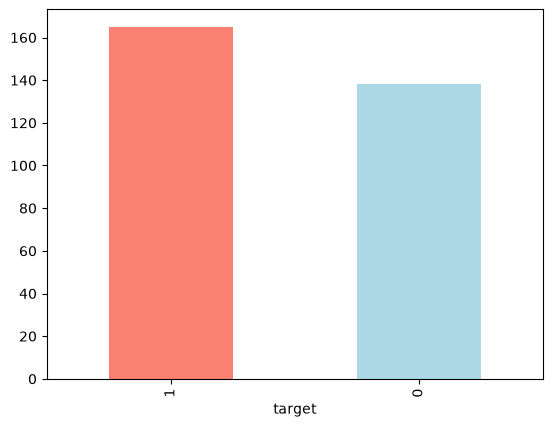

In [8]:
df.target.value_counts().plot(kind="bar", color=["salmon", "lightblue"]);

[`pd.DataFrame.info()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html) mostra rapidamente uma visão geral do número de valores ausentes que temos e do tipo de dado com o qual estamos trabalhando.

No nosso caso, não há valores ausentes e todas as nossas colunas são de natureza numérica.

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


Outra forma de obter uma visão geral rápida do seu DataFrame é usar [`pd.DataFrame.describe()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html). 

`describe()` mostra uma série de métricas diferentes sobre nossas colunas numéricas, como média, máximo e desvio padrão.

In [10]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### 4.1 Comparando uma feature com outra

Se quisermos comparar duas colunas entre si, podemos usar a função [`pd.crosstab(index, columns)`](https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html). 

Isso é útil quando queremos começar a ganhar intuição sobre como nossas variáveis independentes interagem com sua variável dependente.

Vamos comparar nossa coluna target com a coluna sex.

Lembrando do nosso dicionário de dados: para a coluna target, 1 = presença de doença cardíaca, 0 = ausência de doença cardíaca.

E para sex, 1 = masculino, 0 = feminino.

In [11]:
df.sex.value_counts()

sex
1    207
0     96
Name: count, dtype: int64

Há 207 masculinos e 96 femininas no nosso caso.

E se compararmos a os valores da coluna alvo com os valores da coluna sex?

In [12]:
# comparar a coluna alvo com a coluna sex
pd.crosstab(index=df.target, columns=df.sex)

sex,0,1
target,,
0,24,114
1,72,93


O que podemos inferir a partir disso? Vamos criar uma heurística simples.

Como existem cerca de 100 mulheres e 72 delas têm um valor positivo para presença de doença cardíaca, podemos inferir, com base apenas nessa variável, que, se a participante é mulher, há uma chance de ~72% (72/96 mulheres do nosso dataset são positivas para doença cardíaca) de ela ter doença cardíaca.

Já para os homens, são cerca de 200 no total, com aproximadamente metade (93/207) indicando presença de doença cardíaca.

Então poderíamos prever que, se o participante é homem, em 50% dos casos ele terá doença cardíaca.

Fazendo a média desses dois valores, podemos assumir que, sem considerar nenhum outro parâmetro, dada uma pessoa qualquer, há 62,5% de chance de ela ter doença cardíaca.

Essa pode ser nossa **baseline** bem simples, vamos tentar superá-la com machine learning.

> **Nota:** uma baseline é um modelo ou estimativa simples com o qual você começa e tenta superar/confirmar ao longo dos seus experimentos. Pode ser algo tão simples quanto observar os dados, como fizemos aqui, e criar uma heurística preditiva para seguir em frente.

### 4.2 Visualizando nossa comparação

Sempre que estivermos lidando com um novo dataset, é muito útil visualizar o máximo possível, para construir uma ideia do dataset na nossa cabeça.

E uma das melhores formas de criar visualizações é fazer plots (representações gráficas dos nossos dados).

Podemos plotar nossa comparação feita com `pd.crosstab` chamando o método `plot()` passando alguns parâmetros:

* `kind`- O tipo de plot que você quer (ex.: `"bar"` para um gráfico de barras).
* `figsize=(length, width)` - O tamanho que você quer que ele tenha.
* `color=[colour_1, colour_2]` - As diferentes cores que você gostaria de usar.

Métricas diferentes são melhor representadas com tipos diferentes de plots.

No nosso caso, um gráfico de barras é ótimo. Vamos ver outros exemplos mais adiante. E, com um pouco de prática, vamos ganhar intuição sobre qual plot usar com diferentes variáveis.

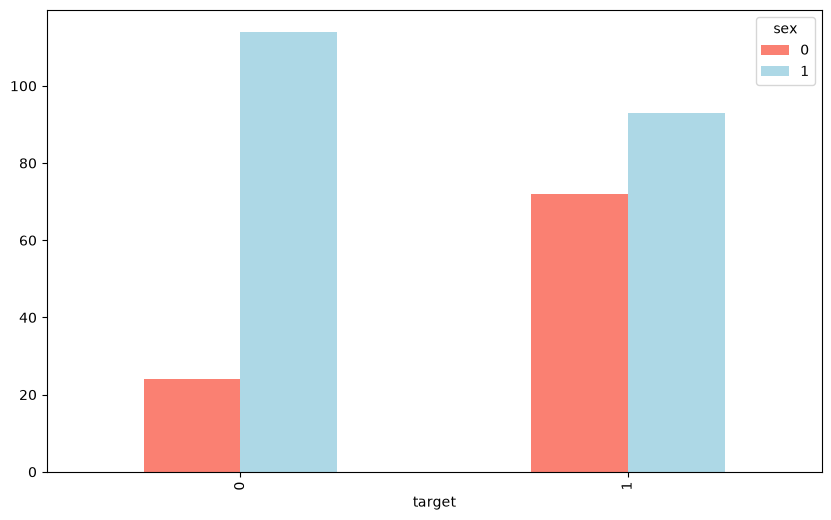

In [13]:
# Plotando
pd.crosstab(df.target, df.sex).plot(kind="bar", 
                                    figsize=(10,6), 
                                    color=["salmon", "lightblue"]);

Legal! Mas nosso gráfico está meio vazio. Vamos adicionar alguns atributos.

Vamos criar o gráfico novamente com `pd.crosstab()` e o método `plot()`.

Depois, como nosso gráfico é construído com o `matplotlib`, podemos adicionar rótulos úteis a ele com [`plt.title()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.title.html), [`plt.xlabel()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xlabel.html), [`plt.legend()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.legend.html) entre outros.

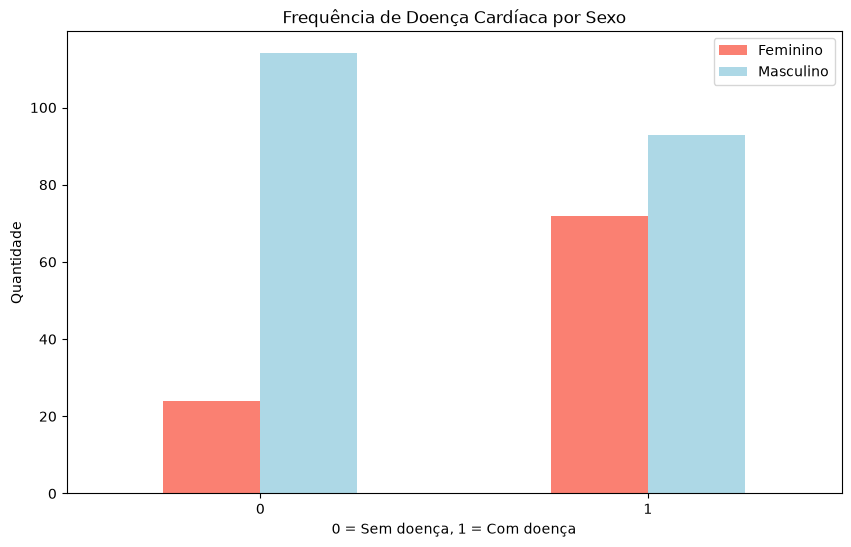

In [14]:
# Plotando
pd.crosstab(df.target, df.sex).plot(kind="bar", figsize=(10,6), color=["salmon", "lightblue"])

# Adicionando algumas variáveis
plt.title("Frequência de Doença Cardíaca por Sexo")
plt.xlabel("0 = Sem doença, 1 = Com doença")
plt.ylabel("Quantidade")
plt.legend(["Feminino", "Masculino"])
plt.xticks(rotation=0); 

### 4.3 Comparando idade e frequência cardíaca máxima

Vamos tentar combinar um par de variáveis independentes, como `age` (idade) e `thalach` (frequência cardíaca máxima), e depois compará-las com nossa variável alvo `heart disease` (doença cardíaca).

Como existem muitos valores diferentes para `age` e `thalach`, vamos usar um scatter plot (gráfico de dispersão).

Text(0, 0.5, 'Frequência Cardíaca Máxima')

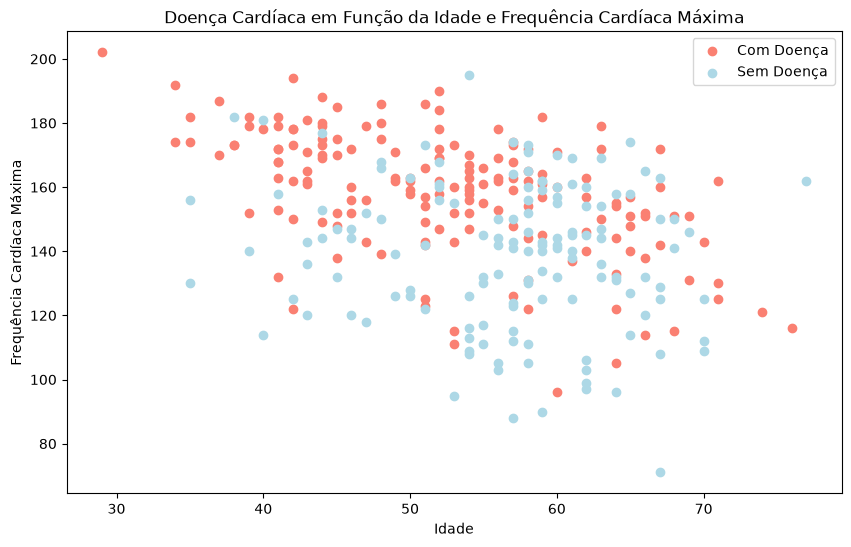

In [15]:
# Cria outra figura
plt.figure(figsize=(10,6))

# Começa com os exemplos positivos
plt.scatter(df.age[df.target==1], 
            df.thalach[df.target==1], 
            c="salmon") # define como um gráfico de dispersão (scatter)

# Agora para os exemplos negativos, queremos eles no mesmo plot, então chamamos plt novamente
plt.scatter(df.age[df.target==0], 
            df.thalach[df.target==0], 
            c="lightblue") # os eixos sempre vêm como (x, y)

# Adiciona algumas informações úteis
plt.title("Doença Cardíaca em Função da Idade e Frequência Cardíaca Máxima")
plt.xlabel("Idade")
plt.legend(["Com Doença", "Sem Doença"])
plt.ylabel("Frequência Cardíaca Máxima")

O que podemos inferir a partir disso?

Parece que, quanto mais jovem a pessoa, maior sua frequência cardíaca máxima (os pontos estão mais altos à esquerda do gráfico), e também parece haver mais doença cardíaca na população mais jovem (mais pontos laranja).

Ambas as observações são, claro, apenas observacionais, mas é exatamente isso que estamos tentando fazer: construir um entendimento sobre os dados.

Vamos verificar a **distribuição** de idade.

> **Nota:** distribuição pode ser entendida como o *espalhamento* (*spread*) dos dados. Ou seja, ao observarmos o conjunto como um todo, quais valores diferentes aparecem nos dados?

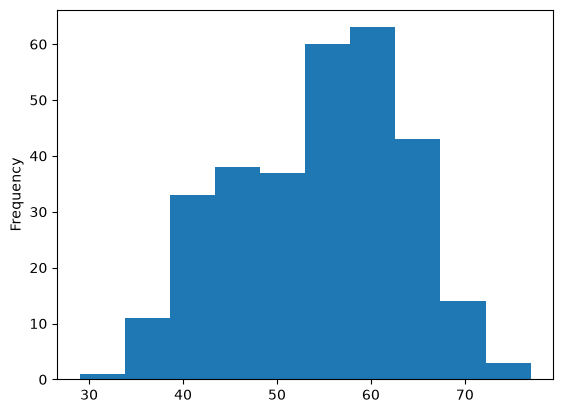

In [16]:
# Hisogramas são uma boa maneira de verificar a distribuição de uma variável
df.age.plot.hist();

Podemos ver que é uma [**normal distribution**](https://en.wikipedia.org/wiki/Normal_distribution) mas levemente inclinada para a direita, o que se reflete no scatter plot acima.

Seguindo...

### 4.4 Comparando frequência de doença cardíaca e tipo de dor no peito

Vamos tentar comparar outra variável independente com a nossa variável alvo.

Dessa vez, vamos usar `cp` (dor no peito) como variável independente.

Vamos usar o mesmo processo que fizemos anteriormente com `sex`.

In [17]:
pd.crosstab(index=df.cp, columns=df.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


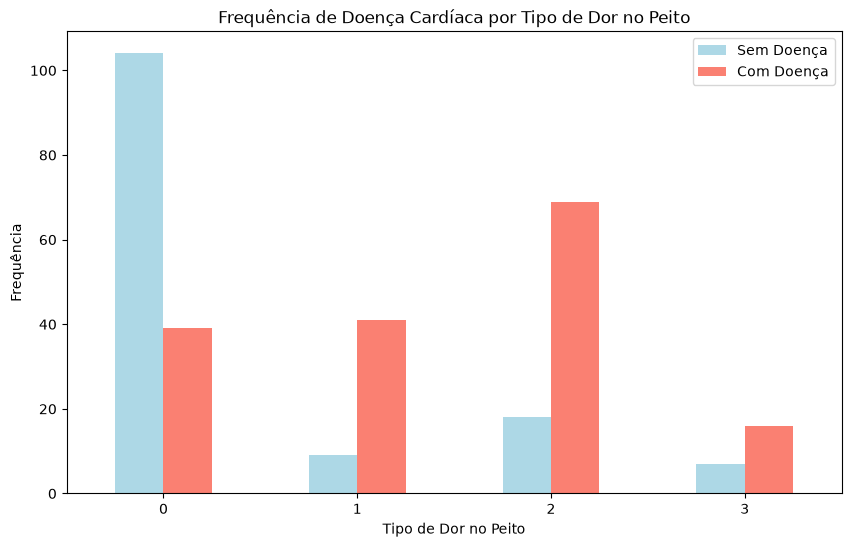

In [18]:
# Cria uma nova crosstab e o plot base
pd.crosstab(df.cp, df.target).plot(kind="bar", 
                                   figsize=(10,6), 
                                   color=["lightblue", "salmon"])

# Adiciona atributos ao plot para deixá-lo mais legível
plt.title("Frequência de Doença Cardíaca por Tipo de Dor no Peito")
plt.xlabel("Tipo de Dor no Peito")
plt.ylabel("Frequência")
plt.legend(["Sem Doença", "Com Doença"])
plt.xticks(rotation = 0);

O que podemos inferir a partir disso?

Vamos relembrar, no nosso dicionário de dados, quais são os diferentes níveis de dor no peito.

| Feature  | Descrição | Valores de Exemplo |
|:-----|:-----|:------|
| **cp**  | Tipo de dor no peito | 0: Angina típica (dor no peito), 1: Angina atípica (dor no peito não relacionada ao coração), 2: Dor não anginosa (tipicamente espasmos esofágicos, não relacionados ao coração), 3: Assintomático (dor no peito sem sinais de doença) |
    
É interessante que a angina atípica (valor 1), apesar de a descrição afirmar que não está relacionada ao coração, parece ter uma proporção maior de participantes com doença cardíaca do que sem.

Espera...

O que "angina atípica" realmente significa?

Nesse ponto, é importante lembrar: se o seu dicionário de dados não fornece informações suficientes, talvez você precise pesquisar mais a fundo sobre os valores.

Essa pesquisa pode vir na forma de perguntar a um **especialista no assunto** (como um cardiologista, ou a pessoa que te forneceu os dados) ou pesquisar no Google para descobrir mais.

De acordo com o PubMed, [parece que até mesmo alguns profissionais da área médica ficam confusos com o termo:](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2763472/).

> Hoje, 23 anos depois, "dor torácica atípica" ainda é um termo popular em círculos médicos. Seu significado, no entanto, permanece pouco claro. Alguns artigos trazem o termo no título, mas não o definem nem o discutem no texto. Em outros artigos, o termo se refere a causas não cardíacas de dor no peito.

Embora não conclusivo, o gráfico acima é um indício de que pode haver uma confusão de definições sendo representada nos dados.

### 4.5 Correlação entre variáveis independentes

Por fim, vamos comparar todas as variáveis independentes de uma só vez.

Por quê?

Porque isso pode nos dar uma ideia de quais variáveis independentes podem ou não ter impacto sobre nossa variável alvo.

Podemos fazer isso usando [`pd.DataFrame.corr()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html), que vai criar uma [**matriz de correlação**](https://en.wikipedia.org/wiki/Correlation#Correlation_matrices) para nós — em outras palavras, uma grande tabela de números nos dizendo o quão relacionada cada variável está com as demais.

In [19]:
# Encontra a correlação entre nossas variáveis independentes
corr_matrix = df.corr()
corr_matrix 

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


Seguindo o lema do explorador de dados de *visualizar, visualizar, visualizar!*, vamos plotar essa matriz.

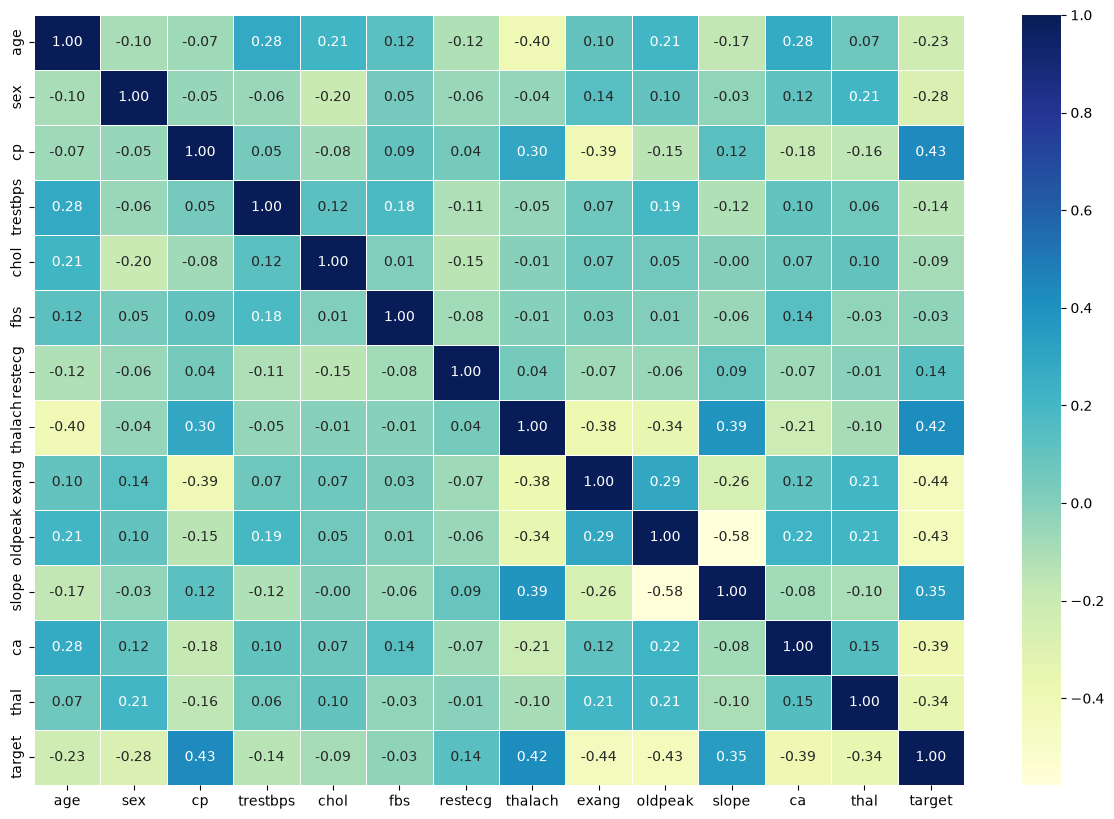

In [20]:
# Vamos deixar mais bonito
corr_matrix = df.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            linewidths=0.5, 
            fmt= ".2f", 
            cmap="YlGnBu");

Bem melhor. Um valor positivo mais alto significa uma potencial correlação positiva (aumento), e um valor negativo mais alto significa uma potencial correlação negativa (diminuição).

### 4.6 Chega de EDA, vamos modelar

Lembrando, fazemos análise exploratória de dados (EDA) para começar a construir uma intuição sobre o dataset.

O que aprendemos até agora?

Além da nossa estimativa de baseline usando `sex`, o restante dos dados parece exigir um pouco mais de exploração antes de tirarmos qualquer conclusão.

Então o que faremos a seguir é uma **EDA orientada por modelo**, ou seja, vamos usar modelos de machine learning para guiar nossas próximas perguntas.

Algumas coisas extras para lembrar:

* Nem toda EDA vai se parecer com esta, o que vimos aqui é um exemplo do que você poderia fazer para um dataset tabular e estruturado.
* Você não precisa necessariamente fazer os mesmos plots que fizemos aqui, existem muitas outras formas de visualizar dados, e eu recomendo explorar mais.
* Frequentemente, vamos querer descobrir:
    * **Distribuições** - Qual é o espalhamento dos dados? Podemos fazer isso com [`pd.DataFrame.hist(column="target_column")`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.hist.html).
    * **Valores ausentes** - Nossos dados têm algo faltando? Por que isso pode estar acontecendo e isso vai nos afetar daqui pra frente? Podemos verificar isso com [`pd.DataFrame.info()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html) ou [`pd.isnull()`](https://pandas.pydata.org/docs/reference/api/pandas.isnull.html).
    * **Outliers** - Existem amostras que ficam bem distantes do restante da distribuição dos nossos dados? Como isso pode afetar os dados daqui pra frente?

Dito isso, vamos construir alguns modelos!

## 5. Modelagem

Exploramos os dados, agora vamos tentar construir um modelo de machine learning capaz de prever nossa variável alvo com base nas 13 variáveis independentes.

Lembra do nosso problema?

> Dados os parâmetros clínicos de um paciente, conseguimos prever se ele tem ou não doença cardíaca?

É isso que vamos tentar responder.

E lembra da nossa métrica de avaliação?

> Se conseguirmos atingir 95% de acurácia ao prever se um paciente tem ou não doença cardíaca durante a prova de conceito, vamos seguir em frente com esse projeto.

É a isso que vamos almejar.

Mas antes de construir um modelo, precisamos deixar nosso dataset pronto.

Vamos dar uma olhada nele de novo.

In [21]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Estamos tentando prever nossa variável alvo usando todas as outras variáveis.

Para isso, vamos separar a variável alvo do restante.

Podemos fazer isso criando:

* `X` - Nossas features (todas as variáveis exceto a coluna `target`) usando [`pd.DataFrame.drop(labels="target")`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop.html).
* `y` - Nossa variável alvo usando [`df.target.to_numpy()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_numpy.html#pandas.DataFrame.to_numpy) (isso vai extrair a coluna `target` como um array NumPy).

In [22]:
# Tudo exceto a variável alvo
X = df.drop(labels="target", axis=1)

# Variável alvo
y = df.target.to_numpy()

Vamos ver nossas novas variáveis.

In [23]:
# Variáveis independentes (sem a coluna target)
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [24]:
# Alvos (na forma de um array NumPy)
y, type(y)

(array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

### 5.1 Criando uma divisão de treino e teste

Agora chega um dos conceitos mais importantes em machine learning: criar uma **divisão de treino/teste**.

Aqui é onde vamos dividir nossos dados em um **conjunto de treino** e um **conjunto de teste**.

Vamos usar nosso conjunto de treino para treinar o modelo, e nosso conjunto de teste para avaliá-lo.

Todas as amostras no conjunto de treino devem ser separadas das que estão no conjunto de teste (e vice-versa).

Resumindo:

* **Conjunto de treino (geralmente 70-80% do total de dados)** - O modelo aprende padrões nesse dataset para, *com sorte*, conseguir prever em amostras semelhantes mas nunca vistas.
* **Conjunto de teste (geralmente 20-30% do total de dados)** - O modelo treinado é avaliado nessas amostras nunca vistas, para ver como os padrões aprendidos no conjunto de treino podem performar em amostras futuras e desconhecidas (por exemplo, quando usado em uma aplicação ou ambiente de produção). Porém, a performance no conjunto de teste não é garantida no mundo real.

#### Por que não usar todos os dados para treinar um modelo?

Digamos que você quisesse levar seu modelo para o hospital e começar a usá-lo em pacientes.

Como você saberia o quão bem seu modelo se sai com um novo paciente que não estava incluído no dataset original completo que você tinha?

É aqui que entra o conjunto de teste.

Ele é usado para simular, o máximo possível, levar seu modelo para um ambiente real.

E é por isso que é importante nunca deixar seu modelo aprender com o conjunto de teste — ele deve apenas ser avaliado nele.

Para dividir nossos dados em conjunto de treino e teste, podemos usar o [`sklearn.model_selection.train_test_split()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do Scikit-Learn e passar nossas variáveis independente e dependente (`X` e `y`).

In [25]:
# Seed aleatória para reprodutibilidade (já que o train_test_split é aleatório por padrão, definir a seed vai criar divisões reproduzíveis)
np.random.seed(42)

# Divide em conjunto de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, # variáveis independentes 
                                                    y, # variável dependente
                                                    test_size = 0.2) # porcentagem dos dados a usar no conjunto de teste

O parâmetro `test_size` é usado para dizer à função `train_test_split()` quanto dos nossos dados queremos no conjunto de teste.

Uma boa regra geral é usar 80% dos seus dados para treinar e os outros 20% para testar.

Para o nosso problema, um conjunto de treino e teste é suficiente. Mas para outros problemas, você também poderia usar um conjunto de validação (treino/validação/teste) ou validação cruzada (veremos isso mais adiante).

Mas, novamente, cada problema vai variar.

Para aprender mais sobre a importância dos conjuntos de validação e teste, eu recomendaria ler:

* [How (and why) to create a good validation set](https://www.fast.ai/2017/11/13/validation-sets/) por Rachel Thomas.
* [The importance of a test set](https://www.learnml.io/posts/the-importance-of-a-test-set/) por Daniel Bourke.

Vamos dar uma olhada nos nossos dados de treino.

In [26]:
X_train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,42,1,1,120,295,0,1,162,0,0.0,2,0,2
202,58,1,0,150,270,0,0,111,1,0.8,2,0,3
196,46,1,2,150,231,0,1,147,0,3.6,1,0,2
75,55,0,1,135,250,0,0,161,0,1.4,1,0,2
176,60,1,0,117,230,1,1,160,1,1.4,2,2,3


In [27]:
y_train, len(y_train)

(array([1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1,
        1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
        0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
        0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0,
        1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
        1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1,
        1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
        0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1,
        1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
        1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1]),
 242)

Lindo, podemos ver que estamos usando 242 amostras para treinar.

Vamos dar uma olhada nos nossos dados de teste.

In [28]:
X_test.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1
228,59,1,3,170,288,0,0,159,0,0.2,1,0,3
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3
246,56,0,0,134,409,0,0,150,1,1.9,1,2,3
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2


In [29]:
y_test, len(y_test)

(array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
        0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0]),
 61)

E temos 61 exemplos nos quais vamos testar nosso(s) modelo(s).

Vamos construir alguns.

### 5.2 Escolhendo um modelo

Agora que temos nossos dados preparados, podemos começar a ajustar modelos.

No mundo moderno de machine learning, existem muitos modelos potenciais entre os quais podemos escolher.

Em vez de tentar todo modelo possível, geralmente é uma boa prática testar alguns poucos e ver como eles se saem.

Vamos começar tentando os seguintes modelos e comparando seus resultados.

1. Logistic Regression (Regressão Logística) - [`sklearn.linear_model.LogisticRegression()`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
2. K-Nearest Neighbors (K-Vizinhos Mais Próximos) - [`sklearn.neighbors.KNeighboursClassifier()`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)
3. RandomForest (Floresta Aleatória) - [`sklearn.ensemble.RandomForestClassifier()`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

#### Por que esses?

Se olharmos o [mapa de algoritmos de machine learning do Scikit-Learn](https://scikit-learn.org/stable/machine_learning_map.html), podemos ver que estamos lidando com um problema de classificação, e esses são os algoritmos que ele sugere (mais alguns outros).

> "Espera, não vejo Logistic Regression, e por que não usar LinearSVC?"

Boas perguntas.

Eu também fiquei confuso quando não vi a Logistic Regression listada, porque quando você lê a documentação do Scikit-Learn sobre ela, dá pra ver que é [um modelo para classificação](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression).

E quanto ao [`sklearn.svm.LinearSVC`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html), vamos fingir que já testamos (você pode testar por conta própria se quiser), e que não funcionou, então estamos seguindo as outras opções do mapa.

Por enquanto, conhecer cada um desses algoritmos a fundo não é essencial (embora isso seria uma extensão fantástica para este projeto).

Machine learning e data science são práticas iterativas.

Esses algoritmos são ferramentas na sua caixa de ferramentas.

No início, no seu caminho para se tornar um praticante, é mais importante entender seu problema (como, classificação versus regressão) e quais ferramentas você pode usar para resolvê-lo.

Já que nosso dataset é relativamente pequeno, podemos rodar alguns experimentos rápidos para ver qual algoritmo performa melhor e tentar melhorá-lo iterativamente.

Muitos dos algoritmos na biblioteca Scikit-Learn têm APIs (Application Programming Interfaces) semelhantes.

Por exemplo, para treinar um modelo você pode usar [`model.fit(X_train, y_train)`](https://scikit-learn.org/stable/glossary.html#term-fit).

E para pontuar um modelo, [`model.score(X_test, y_test)`](https://scikit-learn.org/stable/glossary.html#term-score) (pontuar um modelo compara as previsões com os rótulos verdadeiros).

Para modelos de classificação, chamar `score()` geralmente retorna, por padrão, a proporção (acurácia) de previsões corretas (1.0 = 100% correto).

Já que os algoritmos que escolhemos implementam os mesmos métodos tanto para ajustá-los aos dados quanto para avaliá-los, vamos colocá-los em um dicionário e criar uma função que os ajusta e pontua.

In [30]:
# Coloca os modelos em um dicionário
models = {"KNN": KNeighborsClassifier(),
          "Logistic Regression": LogisticRegression(max_iter=100), # Nota: se você ver um aviso sobre "convergência não atingida", pode aumentar `max_iter` até que a convergência seja atingida
          "Random Forest": RandomForestClassifier()}

# Cria função para ajustar e pontuar os modelos
def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Ajusta e avalia os modelos de machine learning fornecidos.
    models : um dicionário com diferentes modelos de machine learning do Scikit-Learn
    X_train : dados de treino
    X_test : dados de teste
    y_train : rótulos associados aos dados de treino
    y_test : rótulos associados aos dados de teste
    """
    # Seed aleatória para resultados reprodutíveis
    np.random.seed(42)
    # Cria uma lista para guardar os scores dos modelos
    model_scores = {}
    # Percorre os modelos
    for name, model in models.items():
        # Ajusta o modelo aos dados
        model.fit(X_train, y_train)
        # Avalia o modelo e adiciona seu score a model_scores
        model_scores[name] = model.score(X_test, y_test)
    return model_scores

Função construída!

Agora vamos ver como nossa coleção de modelos se sai com nossos dados.

In [31]:
model_scores = fit_and_score(models=models,
                             X_train=X_train,
                             X_test=X_test,
                             y_train=y_train,
                             y_test=y_test)
model_scores

C:\Users\josee\projetos\heart-disease-classification\env\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'KNN': 0.6885245901639344,
 'Logistic Regression': 0.8852459016393442,
 'Random Forest': 0.8360655737704918}

Lindo!

Parece que cada um dos nossos modelos conseguiu se ajustar aos dados sem nenhum erro.

Que tal compará-los visualmente?

### 5.3 Comparando os resultados de vários modelos

Já que salvamos os scores dos nossos modelos em um dicionário, podemos plotá-los convertendo-os primeiro para um DataFrame.

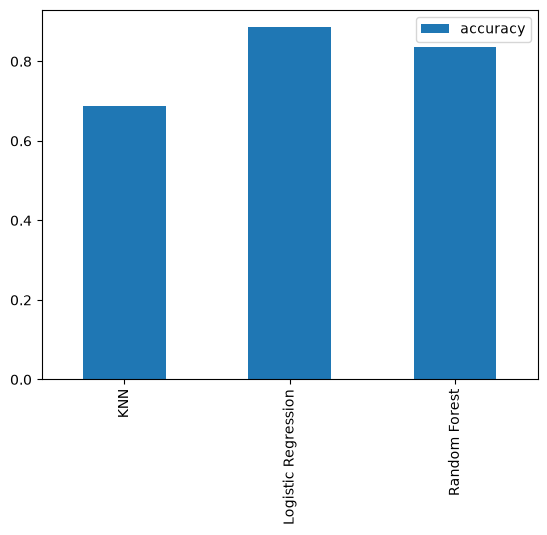

In [32]:
model_compare = pd.DataFrame(model_scores, index=['accuracy'])
model_compare.T.plot.bar();

Lindo!

Pelo plot, parece que o modelo [`sklearn.linear_model.LogisticRegression()`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) performa melhor.

Agora... já que encontramos o melhor modelo.

Vamos levá-lo até a chefe e mostrar o que descobrimos!

### 5.4 Levando nosso melhor modelo até a chefe (e aprendendo alguns termos novos)

*Uma conversa com a chefe/engenheira sênior começa...*

> **Você:** Encontrei!

> **Ela:** Boa! O que você encontrou?
    
> **Você:** O melhor algoritmo para prever doença cardíaca é uma Logistic Regression!

> **Ela:** Excelente. Estou surpresa que o ajuste de hiperparâmetros já esteja terminado.

> **Você:** *se pergunta o que é **ajuste de hiperparâmetros***
    
> **Você:** Hmm, é, eu também, foi bem rápido.
    
> **Ela:** Estou muito orgulhosa, que tal você montar um **relatório de classificação** para mostrar ao time, e não esqueça de incluir uma **matriz de confusão**, e a **precisão**, **recall** e **F1 score** com validação cruzada. Também ficaria curiosa em ver quais **features são mais importantes**. Ah, e não esqueça de incluir uma **curva ROC**.
    
> **Você:** *se pergunta, "o que são essas coisas???"*
    
> **Você:** Claro! Te entrego até amanhã.

Certo, teve umas palavras aí que poderiam soar inventadas para alguém que não é um cientista de dados em ascensão como nós.

Mas, sendo os cientistas de dados em ascensão que somos, também sabemos que cientistas de dados inventam palavras o tempo todo.

Vamos passar rapidamente por cada uma delas antes de vê-las em ação.

| **Termo** | **Definição** |
| :----- | :----- |
| **Ajuste de hiperparâmetros (Hyperparameter tuning)** | Muitos modelos de machine learning têm uma série de configurações/botões que você pode ajustar para ditar como eles performam. Alterar esses valores pode aumentar ou diminuir a performance do modelo. A prática de descobrir as melhores configurações para um modelo é chamada de ajuste de hiperparâmetros. |
| **Importância das features (Feature importance)** | Se há uma grande quantidade de features que estamos usando para fazer previsões, algumas têm mais importância do que outras? Por exemplo, para prever doença cardíaca, o que é mais importante, sexo ou idade? |
| [**Matriz de confusão (Confusion matrix)**](https://www.dataschool.io/simple-guide-to-confusion-matrix-terminology/) | Compara os valores previstos com os valores reais de forma tabular; se 100% correto, todos os valores na matriz estarão do canto superior esquerdo ao inferior direito (linha diagonal). | 
| [**Validação cruzada (Cross-validation)**](https://scikit-learn.org/stable/modules/cross_validation.html) | Divide seu dataset em múltiplas versões de conjuntos de treino e teste, e treina/avalia seu modelo em cada versão diferente. Isso garante que suas métricas de avaliação sejam calculadas em várias divisões diferentes dos dados, em vez de uma única divisão (se fosse apenas uma única divisão, você poderia ter sorte e obter resultados melhores que o normal, e o mesmo vale ao contrário, se você tiver uma divisão ruim, pode achar que suas métricas estão mais baixas do que deveriam). | 
| [**Precisão (Precision)**](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html#sklearn.metrics.precision_score) | Uma métrica comum de avaliação de classificação. Mede a proporção de verdadeiros positivos sobre o número total de amostras. Uma precisão maior leva a menos falsos positivos. |  
[**Recall**](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html#sklearn.metrics.recall_score) | Uma métrica comum de avaliação de classificação. Mede a proporção de verdadeiros positivos sobre o total de verdadeiros positivos e falsos negativos. Um recall maior leva a menos falsos negativos. |
| [**F1 score**](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html#sklearn.metrics.f1_score) | Combina precisão e recall em uma única métrica. 1 é o melhor, 0 é o pior. |
| [**Relatório de classificação (Classification report)**](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) | O Sklearn tem uma função nativa chamada `classification_report()` que retorna algumas das principais métricas de classificação, como precisão, recall e f1-score. |
| [**Curva ROC (ROC Curve)**](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html) | [Receiver Operating Characteristic](https://en.wikipedia.org/wiki/Receiver_operating_characteristic) é um gráfico da taxa de verdadeiros positivos versus a taxa de falsos positivos. Uma curva perfeita seguiria a borda esquerda e superior de um gráfico. | 
| [**Área Sob a Curva (AUC)**](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html) | A área abaixo da curva ROC. Um modelo perfeito atinge um score de 1.0. |

Tem bastante coisa acontecendo aqui, mas nada que não possamos lidar.

Vamos explorar cada uma delas mais a fundo ao longo do restante do notebook.

Enquanto isso, sinta-se à vontade para ler mais nos recursos linkados.

## 6. Ajuste de hiperparâmetros e validação cruzada

Para cozinhar seu prato favorito, você sabe que precisa configurar o forno para 180 graus e ligar o grill.

Mas quando seu colega de apartamento cozinha o prato favorito dele, ele usa 200 graus e o modo turbo (fan-forced).

Mesmo forno, configurações diferentes, resultados diferentes.

O mesmo pode ser feito para algoritmos de machine learning. Você pode usar os mesmos algoritmos, mas mudar as configurações (hiperparâmetros) e obter resultados diferentes.

Mas assim como colocar o forno muito alto pode queimar sua comida, o mesmo pode acontecer com algoritmos de machine learning.

Você muda as configurações e o modelo funciona tão bem, que acaba dando **overfitting** (se saindo bem demais) nos dados.

Estamos procurando pelo modelo que acerta o equilíbrio ideal de complexidade.

Um que se saia bem no nosso dataset de treino, mas também em exemplos nunca vistos, como no dataset de teste/mundo real.

Para testar diferentes hiperparâmetros, você poderia usar um **conjunto de validação**, mas já que não temos muitos dados, vamos usar [**validação cruzada**](https://scikit-learn.org/stable/modules/cross_validation.html).

> **Nota:** Um conjunto de validação é um terceiro participante no jogo da divisão treino/teste. Ele é feito para ser usado entre um conjunto de treino e um de teste. Você pode pensar nele como a prova simulada antes da prova final. Ou seja, o conjunto de treino é o material do curso para aprender, o conjunto de validação é a prova simulada para praticar e ajustar suas habilidades, e o conjunto de teste é a prova final para testar suas habilidades. Em machine learning, o modelo aprende padrões no conjunto de treino, e então você pode ajustar hiperparâmetros para melhorar os resultados no conjunto de validação, antes de finalmente testar seu modelo no conjunto de teste. Todas as amostras nos conjuntos de treino, validação e teste devem se manter exclusivas entre si.

O tipo mais comum de validação cruzada é o *k-fold*.

Ele envolve dividir seus dados em *k-folds*, ou *k diferentes divisões dos dados*, e depois treinar e testar um modelo em cada divisão.

Por exemplo, digamos que tivéssemos 5 folds (k = 5).

É mais ou menos assim que ficaria.

| <img src="../images/sklearn-cross-validation.png" width=500/> | 
|:--:| 
| Divisão normal de treino e teste versus validação cruzada de 5 folds |

Você tem 5 versões diferentes de divisões de treino e teste.

Isso significa que você poderá treinar e testar 5 versões diferentes do seu modelo em divisões diferentes dos dados, e calcular a performance média.

Por que fazer isso?

Isso evita que a gente foque demais nas métricas de uma única divisão dos dados (imagine que a divisão que fizemos contenha todas as amostras fáceis, e as métricas de performance que usamos digam que o modelo performa melhor do que realmente performa).

Vamos usar essa configuração para ajustar os hiperparâmetros de alguns dos nossos modelos e depois avaliá-los.

Também vamos obter algumas métricas a mais, como **precisão**, **recall**, **F1-score** e **ROC**, ao mesmo tempo.

Aqui está o plano:

1. Ajustar os hiperparâmetros do modelo, e ver qual performa melhor
2. Realizar validação cruzada
3. Plotar curvas ROC
4. Criar uma matriz de confusão
5. Obter métricas de precisão, recall e F1-score
6. Encontrar as features mais importantes do modelo

### 6.1 Ajustando o KNeighborsClassifier (K-Vizinhos Mais Próximos ou KNN) manualmente

Existem vários hiperparâmetros que podemos ajustar para o algoritmo K-Nearest Neighbors (KNN) (ou [`sklearn.neighbors.KNeighborsClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)).

Mas por enquanto, vamos começar com um: o número de vizinhos.

O padrão é 5 (`n_neigbors=5`).

O que são vizinhos?

Bem, imagine todas as nossas diferentes amostras em um gráfico, como o scatter plot de várias células acima.

O KNN funciona assumindo que pontos mais próximos entre si pertencem à mesma classe.

Se `n_neighbors=5`, então ele assume que um ponto com os 5 pontos mais próximos ao redor dele estão na mesma classe.

Deixamos alguns detalhes de fora aqui, como o que define "próximo" ou como a distância é calculada, mas eu recomendo que você pesquise isso lendo a documentação.

Por enquanto, vamos testar alguns valores diferentes de `n_neighbors` e ver como os resultados se saem.

In [33]:
# Cria uma lista de scores de treino
train_scores = []

# Cria uma lista de scores de teste
test_scores = []

# Cria uma lista de diferentes valores para n_neighbors
neighbors = range(1, 21) # de 1 a 20

# Configura o algoritmo
knn = KNeighborsClassifier()

# Percorre os diferentes valores de vizinhos
for i in neighbors:
    knn.set_params(n_neighbors = i) # define o valor de vizinhos
    
    # Ajusta o algoritmo
    knn.fit(X_train, y_train)
    
    # Atualiza os scores de treino
    train_scores.append(knn.score(X_train, y_train))
    
    # Atualiza os scores de teste
    test_scores.append(knn.score(X_test, y_test))

Agora vamos olhar os scores de treino do KNN.

In [34]:
train_scores

[1.0,
 0.8099173553719008,
 0.7727272727272727,
 0.743801652892562,
 0.7603305785123967,
 0.7520661157024794,
 0.743801652892562,
 0.7231404958677686,
 0.71900826446281,
 0.6942148760330579,
 0.7272727272727273,
 0.6983471074380165,
 0.6900826446280992,
 0.6942148760330579,
 0.6859504132231405,
 0.6735537190082644,
 0.6859504132231405,
 0.6652892561983471,
 0.6818181818181818,
 0.6694214876033058]

Ok, esses valores estão um pouco difíceis de entender, então vamos seguir o lema do explorador de dados e *visualizar, visualizar, visualizar!* Em outras palavras, vamos plotá-los.

Score máximo do KNN nos dados de teste: 75.41%


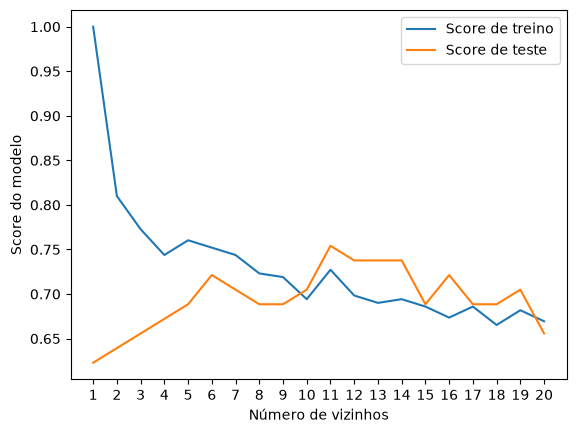

In [35]:
plt.plot(neighbors, train_scores, label="Score de treino")
plt.plot(neighbors, test_scores, label="Score de teste")
plt.xticks(np.arange(1, 21, 1))
plt.xlabel("Número de vizinhos")
plt.ylabel("Score do modelo")
plt.legend()

print(f"Score máximo do KNN nos dados de teste: {max(test_scores)*100:.2f}%")

Olhando o gráfico, `n_neighbors = 11` parece ser o melhor valor.

Mesmo sabendo disso, a performance do modelo `KNN` não chegou perto do que `LogisticRegression` ou `RandomForestClassifier` alcançaram.

Por causa disso, vamos descartar o `KNN` e focar nos outros dois.

Ajustamos o `KNN` manualmente, mas vamos ver como podemos ajustar `LogisticsRegression` e `RandomForestClassifier` usando o [`RandomizedSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html).

Em vez de termos que testar manualmente diferentes hiperparâmetros à mão, o `RandomizedSearchCV` testa uma série de combinações diferentes, avalia cada uma delas e salva a melhor.

### 6.2 Ajustando modelos com [`RandomizedSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)

Lendo a documentação do Scikit-Learn para o [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegressionCV.html#sklearn.linear_model.LogisticRegressionCV), encontramos vários hiperparâmetros diferentes que podemos ajustar.

O mesmo vale para o [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html).

Vamos criar um grid de hiperparâmetros (um dicionário de diferentes hiperparâmetros) para cada um e depois testá-los.

> **Nota:** Tenha cuidado ao criar um dicionário de hiperparâmetros para o ajuste, pois se houver erros de digitação nas chaves do dicionário, seu código de ajuste de hiperparâmetros vai produzir erros.

In [36]:
# Diferentes hiperparâmetros do LogisticRegression
log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver": ["liblinear"]}

# Diferentes hiperparâmetros do RandomForestClassifier
rf_grid = {"n_estimators": np.arange(10, 1000, 50),
           "max_depth": [None, 3, 5, 10],
           "min_samples_split": np.arange(2, 20, 2),
           "min_samples_leaf": np.arange(1, 20, 2)}

Agora vamos usar o [`sklearn.model_selection.RandomizedSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html) para tentar ajustar nosso modelo `LogisticRegression`.

Vamos passar a ele os diferentes hiperparâmetros de `log_reg_grid`, além de definir `n_iter=20`. Isso significa que o `RandomizedSearchCV` vai testar 20 combinações diferentes de hiperparâmetros de `log_reg_grid` e salvar as melhores.

In [37]:
%%time

# Configura a seed aleatória
np.random.seed(42)

# Configura a busca aleatória de hiperparâmetros para o LogisticRegression
rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                                param_distributions=log_reg_grid,
                                cv=5,
                                n_iter=20,
                                verbose=True)

# Ajusta o modelo de busca aleatória de hiperparâmetros
rs_log_reg.fit(X_train, y_train);

Fitting 5 folds for each of 20 candidates, totalling 100 fits
CPU times: total: 828 ms
Wall time: 848 ms


In [38]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': np.float64(0.23357214690901212)}

In [39]:
rs_log_reg.score(X_test, y_test)

0.8852459016393442

Legal! Parece equivalente ao resultado que obtivemos antes *sem* nenhum ajuste de hiperparâmetros.

> **Nota:** Muitos dos algoritmos do Scikit-Learn têm valores de hiperparâmetros padrão bem bons, então não se surpreenda se eles performarem bem nos seus dados logo de cara. Mas não assuma que isso é verdade o tempo todo. Só porque os hiperparâmetros padrão performam relativamente bem nos seus dados não significa que não exista um conjunto melhor de valores de hiperparâmetros por aí.

Agora que ajustamos o `LogisticRegression` usando `RandomizedSearchCV`, vamos fazer o mesmo para o `RandomForestClassifier`.

In [40]:
%%time 

# Configura a seed aleatória
np.random.seed(42)

# Configura a busca aleatória de hiperparâmetros para o RandomForestClassifier
rs_rf = RandomizedSearchCV(RandomForestClassifier(),
                           param_distributions=rf_grid,
                           cv=5,
                           n_iter=20,
                           verbose=True)

# Ajusta o modelo de busca aleatória de hiperparâmetros
rs_rf.fit(X_train, y_train);

Fitting 5 folds for each of 20 candidates, totalling 100 fits
CPU times: total: 1min 38s
Wall time: 1min 42s


In [41]:
# Encontra os melhores parâmetros
rs_rf.best_params_

{'n_estimators': np.int64(210),
 'min_samples_split': np.int64(4),
 'min_samples_leaf': np.int64(19),
 'max_depth': 3}

In [42]:
# Avalia o modelo de floresta aleatória com busca aleatória
rs_rf.score(X_test, y_test)

0.8688524590163934

Excelente! Ajustar os hiperparâmetros de cada modelo trouxe um leve ganho de performance tanto no `RandomForestClassifier` quanto no `LogisticRegression`.

É parecido com ajustar as configurações do seu forno e conseguir deixá-lo no ponto certo para cozinhar seu prato favorito.

Mas já que o `LogisticRegression` está se destacando à frente, vamos tentar ajustá-lo ainda mais com o [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).

### 6.3 Ajustando um modelo com [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)

A diferença entre `RandomizedSearchCV` e `GridSearchCV` é:

* O [`sklearn.model_selection.RandomizedSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html) busca em um grid de hiperparâmetros, realizando `n_iter` combinações (ou seja, explora combinações aleatórias dos hiperparâmetros por um número definido de iterações).
* O [`sklearn.model_selection.GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) vai testar cada combinação possível de hiperparâmetros no grid (esse é um teste minucioso, mas pode levar bastante tempo).

Cada classe vai salvar o melhor modelo ao final dos testes.

Vamos ver isso em ação.

In [43]:
%%time

# Diferentes hiperparâmetros do LogisticRegression
log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver": ["liblinear"]}

# Configura a busca em grid de hiperparâmetros para o LogisticRegression
gs_log_reg = GridSearchCV(LogisticRegression(),
                          param_grid=log_reg_grid,
                          cv=5,
                          verbose=True)

# Ajusta o modelo de busca em grid de hiperparâmetros
gs_log_reg.fit(X_train, y_train);

Fitting 5 folds for each of 20 candidates, totalling 100 fits
CPU times: total: 891 ms
Wall time: 898 ms


In [44]:
# Verifica os melhores parâmetros
gs_log_reg.best_params_

{'C': np.float64(0.23357214690901212), 'solver': 'liblinear'}

In [45]:
# Avalia o modelo
gs_log_reg.score(X_test, y_test)

0.8852459016393442

Nesse caso, obtemos os mesmos resultados de antes, já que nosso grid tem no máximo 20 combinações diferentes de hiperparâmetros.

> **Nota:** Se houver um grande número de combinações de hiperparâmetros no seu grid, o `GridSearchCV` pode demorar bastante para testá-las todas. É por isso que é uma boa ideia começar com o `RandomizedSearchCV`, testar uma certa quantidade de combinações, e depois usar o `GridSearchCV` para refiná-las.

## 7. Avaliando um modelo de classificação, além da acurácia

Agora que temos um modelo ajustado, vamos obter algumas das métricas que discutimos antes.

Queremos:

| Métrica/Técnica de Avaliação | Método/documentação do Scikit-Learn |
| ----- | ----- |
| Curva ROC e score AUC | [`sklearn.metrics.RocCurveDisplay()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html), **Nota:** Isso era anteriormente `sklearn.metrics.plot_roc_curve()`, a partir da versão 1.2+ do Scikit-Learn, agora é `sklearn.metrics.RocCurveDisplay()`. |
| Matriz de confusão | [`sklearn.metrics.confusion_matrix()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) |
| Relatório de classificação | [`sklearn.metrics.classification_report()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) |
| Precisão | [`sklearn.metrics.precision_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html) |
| Recall | [`sklearn.metrics.recall_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html) |
| F1-score | [`sklearn.metrics.f1_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html) | 

Por sorte, o Scikit-Learn já tem tudo isso nativamente.

O que muitas métricas de avaliação têm em comum é que elas comparam as previsões do modelo com os dados reais (ground truth).

Então vamos precisar de algumas previsões do modelo!

Para obtê-las, vamos ter que usar nosso modelo para fazer previsões no conjunto de teste.

Podemos fazer previsões chamando `predict()` em um modelo treinado e passando a ele os dados nos quais você gostaria de prever.

Vamos fazer previsões nos dados de teste.

> **Nota:** Ao fazer previsões com um modelo treinado, os dados nos quais você está tentando prever devem estar no mesmo formato em que o modelo foi treinado. Por exemplo, se um modelo foi treinado com dados formatados de uma certa maneira, é importante fazer futuras previsões em dados formatados da mesma maneira.

In [46]:
# Faz previsões nos dados de teste
y_preds = gs_log_reg.predict(X_test)

Vamos vê-las.

In [47]:
y_preds

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

Elas se parecem com os rótulos originais dos nossos dados de teste, exceto onde o modelo previu errado.

In [48]:
y_test

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

Já que temos nossos valores previstos, podemos calcular as métricas que queremos.

Vamos começar com a curva ROC e os scores AUC.

### 7.1 Curva ROC e Scores AUC

O que é uma curva ROC?

É uma forma de entender como seu modelo está performando, comparando a taxa de verdadeiros positivos com a taxa de falsos positivos.

No nosso caso...

> Para ter um exemplo adequado em um problema do mundo real, considere um teste diagnóstico que busca determinar se uma pessoa tem uma certa doença. Um falso positivo, nesse caso, ocorre quando a pessoa testa positivo, mas na verdade não tem a doença. Um falso negativo, por outro lado, ocorre quando a pessoa testa negativo, sugerindo que está saudável, quando na verdade tem a doença.

O Scikit-Learn implementa uma função chamada `RocCurveDisplay` (anteriormente chamada de `plot_roc_curve` em versões do Scikit-Learn < 1.2), que pode nos ajudar a criar uma curva ROC, além de calcular a métrica de área sob a curva (AUC).

Lendo a documentação da função [`RocCurveDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html), podemos ver que ela tem um método de classe chamado [`from_estimator(estimator, X, y)`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html#sklearn.metrics.RocCurveDisplay.from_estimator) como entradas.

Onde `estimator` é um modelo de machine learning já ajustado, e `X` e `y` são os dados nos quais você gostaria de testá-lo.

No nosso caso, vamos usar a versão GridSearchCV do nosso estimador `LogisticRegression`, `gs_log_reg`, além dos dados de teste, `X_test` e `y_test`.

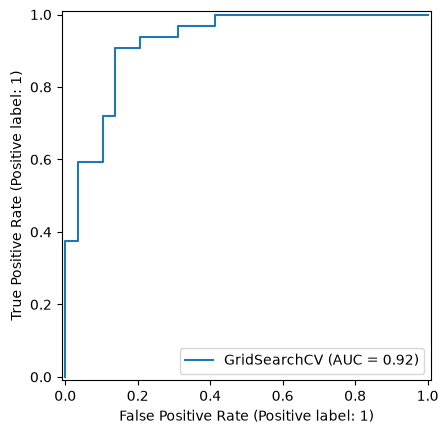

In [49]:
# Antes do Scikit-Learn 1.2.0 (vai dar erro em versões 1.2+)
# from sklearn.metrics import plot_roc_curve 
# plot_roc_curve(gs_log_reg, X_test, y_test);

# Scikit-Learn 1.2.0 ou posterior
from sklearn.metrics import RocCurveDisplay 

# from_estimator() = usa um modelo para plotar a curva ROC nos dados
RocCurveDisplay.from_estimator(estimator=gs_log_reg, 
                               X=X_test, 
                               y=y_test); 

Isso é ótimo, nosso modelo se sai muito melhor do que o "chute" aleatório, que seria uma linha indo do canto inferior esquerdo ao canto superior direito, AUC = 0.5.

Mas um modelo perfeito atingiria um score AUC de 1.0, então ainda há espaço para melhorias.

Vamos seguir para a próxima solicitação de avaliação, uma matriz de confusão.

### 7.2 Criando uma matriz de confusão

Uma matriz de confusão é uma forma visual de mostrar onde seu modelo fez previsões corretas e onde ele fez previsões erradas (ou, em outras palavras, "se confundiu").

O Scikit-Learn nos permite criar uma matriz de confusão usando [`sklearn.metrics.confusion_matrix()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) e passando a ele os rótulos verdadeiros e os rótulos previstos.

In [50]:
# Exibe a matriz de confusão
print(confusion_matrix(y_test, y_preds))

[[25  4]
 [ 3 29]]


Como você pode ver, a matriz de confusão nativa do Scikit-Learn é meio sem graça. Para uma apresentação, você provavelmente gostaria de deixá-la mais visual.

Vamos criar uma função que usa o [`heatmap()`](https://seaborn.pydata.org/generated/seaborn.heatmap.html) do Seaborn para isso.

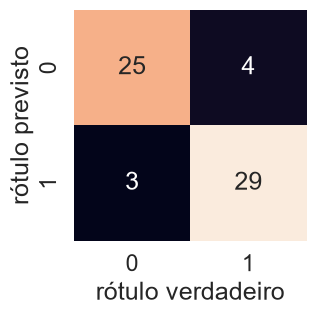

In [51]:
# Importa o Seaborn
import seaborn as sns
sns.set(font_scale=1.5) # Aumenta o tamanho da fonte

def plot_conf_mat(y_test, y_preds):
    """
    Plota uma matriz de confusão usando o heatmap() do Seaborn.
    """
    fig, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True, # Anota as caixas
                     cbar=False)
    plt.xlabel("rótulo verdadeiro")
    plt.ylabel("rótulo previsto")
    
plot_conf_mat(y_test, y_preds)

Ficou muito melhor.

Você pode ver que o modelo se confunde (prevê o rótulo errado) de forma relativamente parecida entre as duas classes.

Em essência, há 4 ocasiões em que o modelo previu 0 quando deveria ser 1 (falso negativo), e 3 ocasiões em que o modelo previu 1 em vez de 0 (falso positivo).

Como avaliação adicional, poderíamos investigar essas amostras e entender por que isso pode estar acontecendo.

### 7.3 Relatório de classificação

Um relatório de classificação é uma coleção de diferentes métricas e outros detalhes.

Podemos criar um relatório de classificação usando [`sklearn.metrics.classification_report(y_true, y_pred)`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) e passando a ele os rótulos verdadeiros, além dos rótulos previstos pelo nosso modelo.

Um relatório de classificação também vai nos dar informações sobre a precisão e o recall do nosso modelo para cada classe.

In [52]:
# Exibe o relatório de classificação
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



O que está acontecendo aqui?

Vamos relembrar as métricas acima.

| **Métrica/metadado** | **Explicação** | 
| ----- | ----- | 
| **Precisão (Precision)** | Indica a proporção de identificações positivas (o modelo previu classe 1) que estavam realmente corretas. Um modelo que não produz falsos positivos tem precisão de 1.0. |
| **Recall** | Indica a proporção de positivos reais que foram corretamente classificados. Um modelo que não produz falsos negativos tem recall de 1.0. |
| **F1 score** | Uma combinação de precisão e recall. Um modelo perfeito atinge um F1 score de 1.0. |
| **Support** | O número de amostras usado para calcular cada métrica. |
| **Acurácia (Accuracy)** | A acurácia do modelo em forma decimal. A acurácia perfeita é igual a 1.0. |
| **Macro avg** | Abreviação de média macro, a média de precisão, recall e F1 score entre as classes. A macro avg não leva em conta o desbalanceamento de classes, então, se você tiver classes desbalanceadas, preste atenção nessa métrica. |
| **Weighted avg** | Abreviação de média ponderada, a média ponderada de precisão, recall e F1 score entre as classes. Ponderada significa que cada métrica é calculada considerando quantas amostras existem em cada classe. Essa métrica vai favorecer a classe majoritária (por exemplo, vai dar um valor alto quando uma classe se sai melhor que outra por ter mais amostras). |

Ok, agora temos algumas percepções mais profundas sobre nosso modelo.

Mas todas elas foram calculadas usando uma única divisão de treino e teste.

O que vamos fazer para torná-las mais sólidas é calculá-las usando validação cruzada.

Como?

Vamos pegar o melhor modelo, junto com os melhores hiperparâmetros, e usar o [`cross_val_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) com vários valores do parâmetro `scoring`.

O `cross_val_score()` funciona recebendo um estimador (modelo de machine learning), junto com dados e rótulos.

Ele então avalia o modelo de machine learning nos dados e rótulos usando validação cruzada com `cv=5` (o número padrão de divisões) divisões, e um parâmetro `scoring` definido.

Vamos relembrar os melhores hiperparâmetros e depois vê-los em ação.

In [53]:
# Verifica os melhores hiperparâmetros
gs_log_reg.best_params_

{'C': np.float64(0.23357214690901212), 'solver': 'liblinear'}

In [54]:
# Importa cross_val_score
from sklearn.model_selection import cross_val_score

# Instancia o melhor modelo com os melhores hiperparâmetros (encontrados com GridSearchCV)
clf = LogisticRegression(C=0.23357214690901212,
                         solver="liblinear")

Agora que temos um classificador instanciado, vamos encontrar algumas métricas com validação cruzada.

In [55]:
%%time

# Score de acurácia com validação cruzada
cv_acc = cross_val_score(clf,
                         X,
                         y,
                         cv=5, # validação cruzada de 5 folds, esse é o padrão
                         scoring="accuracy") # acurácia como métrica
cv_acc

CPU times: total: 46.9 ms
Wall time: 51.4 ms


array([0.81967213, 0.90163934, 0.8852459 , 0.88333333, 0.75      ])

Uau!

A saída de `cross_val_score()` mostra 5 métricas diferentes em diferentes divisões dos dados.

Isso mostra o poder da validação cruzada.

Se tivéssemos escolhido usar apenas os resultados de uma única divisão dos dados, poderíamos estar achando que nosso modelo está performando pior ou melhor do que realmente está.

Já que temos 5 métricas aqui, vamos calcular a média.

In [56]:
cv_acc = np.mean(cv_acc)
cv_acc

np.float64(0.8479781420765027)

Agora vamos fazer o mesmo para as outras métricas de classificação.

In [57]:
# Score de precisão com validação cruzada
cv_precision = np.mean(cross_val_score(clf,
                                       X,
                                       y,
                                       cv=5, # validação cruzada de 5 folds
                                       scoring="precision")) # precisão como métrica
cv_precision

np.float64(0.8215873015873015)

In [58]:
# Score de recall com validação cruzada
cv_recall = np.mean(cross_val_score(clf,
                                    X,
                                    y,
                                    cv=5, # validação cruzada de 5 folds
                                    scoring="recall")) # recall como métrica
cv_recall

np.float64(0.9272727272727274)

In [59]:
# Score F1 com validação cruzada
cv_f1 = np.mean(cross_val_score(clf,
                                X,
                                y,
                                cv=5, # validação cruzada de 5 folds
                                scoring="f1")) # f1 como métrica
cv_f1

np.float64(0.8705403543192143)

Ok, temos as métricas com validação cruzada, e agora?

Vamos visualizá-las.

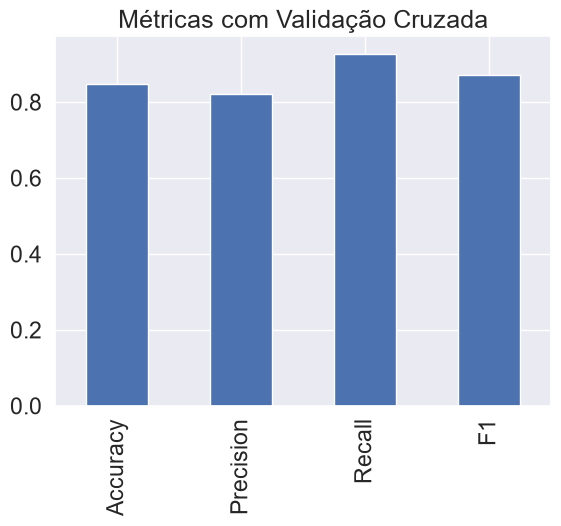

In [60]:
# Visualizando as métricas com validação cruzada
cv_metrics = pd.DataFrame({"Accuracy": cv_acc,
                            "Precision": cv_precision,
                            "Recall": cv_recall,
                            "F1": cv_f1},
                          index=[0])
cv_metrics.T.plot.bar(title="Métricas com Validação Cruzada", legend=False);

Ótimo! Parece algo que poderíamos compartilhar. Uma extensão poderia ser adicionar as métricas em cima de cada barra, para que alguém consiga identificar rapidamente quais são os valores.

E agora?

A última coisa a marcar na nossa lista de técnicas de avaliação de modelo é a importância das features.

## 8. Importância das features

Importância das features é outra forma de perguntar: "Quais features contribuem mais para os resultados do modelo?"

Para o nosso problema, tentando prever doença cardíaca usando as características médicas de um paciente, obter a importância das features é como perguntar "Quais características contribuem mais para um modelo prever se alguém tem doença cardíaca ou não?"

Como cada modelo encontra padrões nos dados de forma um pouco diferente, a forma como um modelo julga a importância desses padrões também é diferente.

Isso significa que, para cada modelo, existe uma forma um pouco diferente de descobrir quais features foram mais importantes, e, por sua vez, a importância das features de um modelo não vai necessariamente refletir a importância das features de outro.

Você geralmente consegue encontrar um exemplo através da documentação do Scikit-Learn, ou pesquisando por algo como "TIPO DE MODELO feature importance", como, "random forest feature importance".

Já que estamos usando `LogisticRegression`, vamos ver uma forma de calcular a importância das features para ele.

Para isso, vamos usar o atributo `coef_`. Olhando a [documentação do Scikit-Learn para `LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html), o atributo `coef_` é o coeficiente das features na função de decisão.

Podemos acessar o atributo `coef_` depois de termos ajustado uma instância de `LogisticRegression`.

In [61]:
# Ajusta uma instância de LogisticRegression (retirada de acima)
clf.fit(X_train, y_train);

In [62]:
# Verifica coef_
clf.coef_

array([[ 0.00369922, -0.90424098,  0.67472823, -0.0116134 , -0.00170364,
         0.04787687,  0.33490208,  0.02472938, -0.63120414, -0.57590996,
         0.47095166, -0.65165344, -0.69984217]])

Olhando para isso, talvez não faça muito sentido ainda. Mas esses valores representam o quanto cada feature contribui para como um modelo decide se os padrões em uma amostra dos dados de saúde de um paciente pendem mais para ter doença cardíaca ou não.

Mesmo sabendo disso, no seu formato atual, esse array `coef_` ainda não diz muita coisa. Mas vai fazer sentido se combinarmos com as colunas (features) do nosso dataframe.

In [63]:
# Combina as features com as colunas
features_dict = dict(zip(df.columns, list(clf.coef_[0])))
features_dict

{'age': np.float64(0.003699223396114675),
 'sex': np.float64(-0.9042409779785583),
 'cp': np.float64(0.6747282348693419),
 'trestbps': np.float64(-0.011613398123390507),
 'chol': np.float64(-0.0017036431858934173),
 'fbs': np.float64(0.0478768694057663),
 'restecg': np.float64(0.33490207838133623),
 'thalach': np.float64(0.024729380915946855),
 'exang': np.float64(-0.6312041363430085),
 'oldpeak': np.float64(-0.5759099636629296),
 'slope': np.float64(0.47095166489539353),
 'ca': np.float64(-0.6516534354909507),
 'thal': np.float64(-0.6998421698316164)}

Agora que combinamos os coeficientes das features com as diferentes features, vamos visualizá-los.

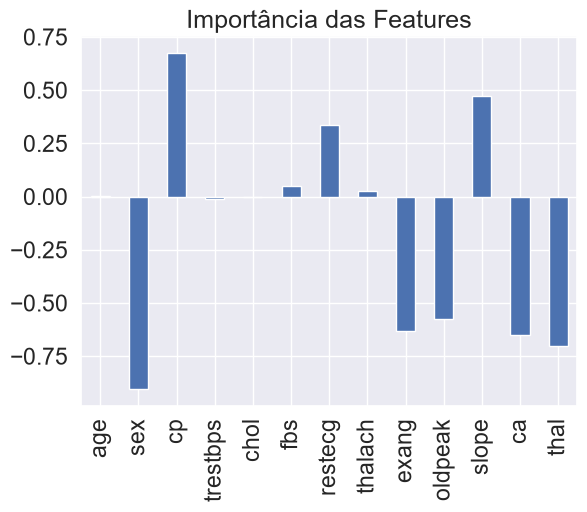

In [64]:
# Visualiza a importância das features
features_df = pd.DataFrame(features_dict, index=[0])
features_df.T.plot.bar(title="Importância das Features", legend=False);

Você vai notar que alguns valores são negativos e outros positivos.

Quanto maior o valor (barra maior), mais a feature contribui para a decisão do modelo.

Se o valor for negativo, significa que há uma correlação negativa. E vice-versa para valores positivos.

Por exemplo, o atributo `sex` tem um valor negativo de -0.904, o que significa que, conforme o valor de `sex` aumenta, o valor de `target` diminui.

Podemos ver isso comparando a coluna `sex` com a coluna `target`.

In [65]:
pd.crosstab(df["sex"], df["target"])

target,0,1
sex,,
0,24,72
1,114,93


Você pode ver que, quando `sex` é 0 (feminino), há quase 3 vezes mais (72 vs. 24) pessoas com doença cardíaca (`target` = 1) do que sem.

E depois, conforme `sex` aumenta para 1 (masculino), a proporção cai para quase 1 para 1 (114 vs. 93) de pessoas que têm doença cardíaca e que não têm.

O que isso significa?

Significa que o modelo encontrou um padrão que reflete os dados. Olhando para esses números e para esse dataset específico, parece que, se a paciente é do sexo feminino, ela tem mais chances de ter doença cardíaca.

E quanto a uma correlação positiva?

In [66]:
# Contrasta slope (coeficiente positivo) com target
pd.crosstab(df["slope"], df["target"])

target,0,1
slope,,
0,12,9
1,91,49
2,35,107


Olhando novamente o dicionário de dados, vemos que `slope` é a "inclinação do segmento ST no pico do exercício", onde:
* 0: Ascendente (Upsloping): melhor frequência cardíaca com exercício (incomum)
* 1: Plana (Flatsloping): mudança mínima (coração saudável típico)
* 2: Descendente (Downslopins): sinais de coração não saudável
    
De acordo com o modelo, há uma correlação positiva de 0.470, não tão forte quanto `sex` e `target`, mas ainda assim maior que 0.

Essa correlação positiva significa que nosso modelo está captando o padrão de que, conforme `slope` aumenta, `target` também aumenta.

Isso é verdade?

Quando você olha o contraste (`pd.crosstab(df["slope"], df["target"]`), sim. Conforme `slope` sobe, `target` também sobe.

O que você pode fazer com essa informação?

Isso é algo que você talvez queira conversar com um especialista no assunto. 

Ele(a) pode ter interesse em ver onde o modelo de machine learning está encontrando mais padrões (correlação mais alta), assim como onde não está (correlação mais baixa).

Fazer isso traz alguns benefícios:
1. **Descobrir mais** - Se algumas das correlações e importâncias de features estiverem confusas, um especialista no assunto pode ajudar a esclarecer a situação e te ajudar a descobrir mais.
2. **Redirecionar esforços** - Se algumas features oferecem muito mais valor do que outras, isso pode mudar como você coleta dados para diferentes problemas. Veja o ponto 3.
3. **Menos, porém melhor** - De forma parecida com o item acima, se algumas features estão oferecendo muito mais valor do que outras, você poderia reduzir o número de features nas quais seu modelo tenta encontrar padrões, além de melhorar as que oferecem mais valor. Isso poderia potencialmente economizar em processamento, já que um modelo encontraria padrões em menos features, mantendo os mesmos níveis de performance.

## 9. Experimentação

Concluímos todas as métricas que queríamos!!

Conseguiriamos montar um bom relatório contendo uma matriz de confusão e algumas métricas com validação cruzada, como precisão, recall e F1-score, e até incluir quais features mais contribuem para o modelo tomar uma decisão.

Mas depois de tudo isso, você pode estar se perguntando onde está o passo 6 do framework, a experimentação.

Aí que está: tudo isso já é experimentação.

Desde testar diferentes modelos, até ajustar diferentes modelos e descobrir quais hiperparâmetros eram os melhores.

O que fizemos até agora foi uma série de experimentos.

E a verdade é que poderíamos continuar. Mas, claro, as coisas não podem continuar para sempre.

Então, nesse ponto, depois de tentar algumas coisas diferentes, devemos nos perguntar: atingimos a métrica de avaliação?

Lembre-se que definimos uma no passo 3.

> Se conseguirmos atingir 95% de acurácia ao prever se um paciente tem ou não doença cardíaca durante a prova de conceito, vamos seguir em frente com esse projeto.

Nesse caso, não atingimos.

A maior acurácia que nosso modelo alcançou ficou abaixo de 90%.

## E agora?

Então, o que acontece quando nossa métrica de avaliação não foi atingida?

Tudo o que fizemos foi em vão?

Não.

Isso significa que sabemos o que não funciona.

Nesse caso, sabemos que o modelo atual que estamos usando (uma versão ajustada do [`sklearn.linear_model.LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)), junto com nosso dataset específico, não atinge a meta que estabelecemos para nós mesmos.

É aqui que o passo 6 se torna essencial.

Um bom próximo passo seria discutir com seu time, ou pesquisar por conta própria, diferentes opções de seguir em frente.

* Você poderia coletar mais dados? Envolvendo mais pacientes e mais features? Isso pode levar um tempo, mas em machine learning, mais dados geralmente é melhor.
* Você poderia tentar um modelo melhor? Se você está trabalhando com dados estruturados, talvez queira olhar o [CatBoost](https://catboost.ai/) ou o [XGBoost](https://xgboost.ai/).
* Você poderia melhorar os modelos atuais (além do que já fizemos até aqui)?
* Se seu modelo estiver bom o suficiente, como você o exportaria e compartilharia com outras pessoas? (Dica: confira a [documentação do Scikit-Learn sobre persistência de modelos](https://scikit-learn.org/stable/modules/model_persistence.html))

O ponto chave aqui é lembrar que sua maior restrição vai ser o tempo.

Por isso é fundamental minimizar o tempo entre experimentos (se possível).

Quanto mais coisas você testar, mais você vai descobrir o que não funciona, e mais você vai começar a pegar o jeito do que funciona.

E essa é a natureza de todo o machine learning.